In [11]:
%cd /content

/content


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/Guava_disease"
!unzip -q "/content/drive/MyDrive/Guava_disease/Dataset.zip" \
-d "/content/drive/MyDrive/Guava_disease/Dataset"

Dataset      model
Dataset.zip  MS_Final_Project_transfer_learning_feature_extraction.ipynb
replace /content/drive/MyDrive/Guava_disease/Dataset/test/Canker/test_0_1262.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/Guava_disease/Dataset/test/Canker/test_0_1354.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
from __future__ import print_function, division
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.autograd import Variable
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
from PIL import Image
import time
import os
import copy
import torch
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
import time
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from torchsummary import summary

print("PyTorch Version: ",torch.__version__)
print("Torchvision Version: ",torchvision.__version__)

root_dir = "/content/drive/My Drive/"
project_folder = "Guava_disease/"
os.chdir(root_dir+project_folder)
!pwd

plt.ion()

# import warnings
# warnings.filterwarnings('ignore')

use_gpu = torch.cuda.is_available()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if use_gpu:
    print("Using CUDA")
else:
  print("Not Using CUDA")

PyTorch Version:  2.9.0+cu126
Torchvision Version:  0.24.0+cu126
/content/drive/My Drive/Guava_disease
Using CUDA


In [6]:
# Top level data directory. Here we assume the format of the directory conforms
#   to the ImageFolder structure
data_dir = "/content/drive/My Drive/Guava_disease/Dataset"

# Models to choose from [resnet, alexnet, vgg, squeezenet, densenet, inception]
model_name = "resnet"

# Number of classes in the dataset
num_classes = 5

# Batch size for training (change depending on how much memory you have)
batch_size = 8

# Number of epochs to train for
num_epochs = 35

# Flag for feature extracting. When False, we finetune the whole model,
#   when True we only update the reshaped layer params
feature_extract = True

# Model will be train when true
train_model = True

# Make new split on dataset
dataset_split = False

In [7]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25, is_inception=False):
    since = time.time()

    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    # Get model outputs and calculate loss
                    # Special case for inception because in training it has an auxiliary output. In train
                    #   mode we calculate the loss by summing the final output and the auxiliary output
                    #   but in testing we only consider the final output.
                    if is_inception and phase == 'train':
                        # From https://discuss.pytorch.org/t/how-to-optimize-inception-model-with-auxiliary-classifiers/7958
                        outputs, aux_outputs = model(inputs)
                        loss1 = criterion(outputs, labels)
                        loss2 = criterion(aux_outputs, labels)
                        loss = loss1 + 0.4*loss2
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
            if phase == 'val':
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc)
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc)

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, train_loss_history, train_acc_history, val_loss_history, val_acc_history

In [8]:
# ---- Test evaluation helpers ----
test_acc_results = {}

def compute_test_accuracy(model, dataloader, device):
    """Compute accuracy on the given dataloader (e.g., test)."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            # Inception safety: sometimes returns (logits, aux_logits)
            if isinstance(outputs, (tuple, list)):
                outputs = outputs[0]
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total if total > 0 else 0.0

def evaluate_model(model, dataloader, criterion, device):
    """Evaluate the model on the given dataloader and return loss and accuracy."""
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            if isinstance(outputs, (tuple, list)):
                outputs = outputs[0]
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += (preds == labels).sum().item()
            total += labels.size(0)
    epoch_loss = running_loss / total if total > 0 else 0.0
    epoch_acc = running_corrects / total if total > 0 else 0.0
    return epoch_loss, epoch_acc

In [12]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [9]:
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    model_ft = None
    input_size = 0

    if model_name == "resnet":
        model_ft = models.resnet50(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    elif model_name == "alexnet":
        model_ft = models.alexnet(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    elif model_name == "vgg":
        model_ft = models.vgg16_bn(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    elif model_name == "squeezenet":
        model_ft = models.squeezenet1_0(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        model_ft.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1, 1), stride=(1, 1))
        model_ft.num_classes = num_classes
        input_size = 224

    elif model_name == "densenet":
        model_ft = models.densenet169(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier.in_features
        model_ft.classifier = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    elif model_name == "inception":
        model_ft = models.inception_v3(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)

        num_ftrs = model_ft.AuxLogits.fc.in_features
        model_ft.AuxLogits.fc = nn.Linear(num_ftrs, num_classes)

        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)

        input_size = 299

    elif model_name == "efficientnet":
        """ EfficientNet-B1 """
        model_ft = models.efficientnet_b1(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)

        num_ftrs = model_ft.classifier[1].in_features
        model_ft.classifier[1] = nn.Linear(num_ftrs, num_classes)

        input_size = 224

    else:
        raise ValueError("Invalid model name, exiting...")

    return model_ft, input_size


In [ ]:
# Dataset Exploration Cell
# This cell loads the datasets and displays information and samples, independent of training.

import os
from torchvision import datasets, transforms
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Assuming data_dir is set from earlier cells
# If not, uncomment and set: data_dir = "/content/drive/My Drive/Guava_disease/Dataset"

# Define transforms (basic for exploration)
input_size = 224  # Default, adjust if needed
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(input_size),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
    'val': transforms.Compose([
        transforms.Resize(input_size),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
    'test': transforms.Compose([
        transforms.Resize(input_size),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
}

# Load datasets
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val', 'test']}

# Dataset Information
print("Dataset Information:")
print(f"Number of classes: {len(image_datasets['train'].classes)}")
print(f"Class names: {image_datasets['train'].classes}")
print(f"Number of images - Train: {len(image_datasets['train'])}, Val: {len(image_datasets['val'])}, Test: {len(image_datasets['test'])}")

train_targets = [image_datasets['train'][i][1] for i in range(len(image_datasets['train']))]
print(f"Train class distribution: {dict(Counter(train_targets))}")

# Show sample images with labels
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Create dataloader for samples
dataloaders_dict = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True if x=='train' else False, num_workers=2) for x in ['train', 'val', 'test']}

# Get a batch of training data
inputs, classes = next(iter(dataloaders_dict['train']))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[image_datasets['train'].classes[x] for x in classes])

plt.show()

Dataset Information:
Number of classes: 5
Class names: ['Canker', 'Dot', 'Healthy', 'Mummification', 'Rust']
Number of images - Train: 1377, Val: 457, Test: 465


KeyboardInterrupt: 

In [ ]:
if train_model:
    # [resnet, alexnet, vgg, squeezenet, densenet, inception]
    model_name = "resnet"
    feature_extract = False

    # Initialize the model for this run
    model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

    # Print the model we just instantiated
    print(model_ft)

    # Data augmentation and normalization for training
    # Just normalization for validation
    data_transforms = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(input_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'val': transforms.Compose([
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'test': transforms.Compose([   # ✅ ADD THIS
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
         ]),
    }

    print("Initializing Datasets and Dataloaders...")

    # Create training validation and Test datasets
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val', 'test']}
    # Create training validation and Test dataloaders
    dataloaders_dict = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True if x=='train' else False, num_workers=2) for x in ['train', 'val', 'test']}

    # Detect if we have a GPU available
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # Send the model to GPU
    model_ft = model_ft.to(device)
    summary(model_ft, (3, input_size, input_size))
    # Gather the parameters to be optimized/updated in this run. If we are
    #  finetuning we will be updating all parameters. However, if we are
    #  doing feature extract method, we will only update the parameters
    #  that we have just initialized, i.e. the parameters with requires_grad
    #  is True.
    params_to_update = model_ft.parameters()
    print("Params to learn:")
    if feature_extract:
        params_to_update = []
        for name,param in model_ft.named_parameters():
            if param.requires_grad == True:
                params_to_update.append(param)
                print("\t",name)
    else:
        for name,param in model_ft.named_parameters():
            if param.requires_grad == True:
                print("\t",name)

    # Observe that all parameters are being optimized
    optimizer_ft = optim.SGD(params_to_update, lr=0.001, momentum=0.9)

    # Setup the loss fxn
    criterion = nn.CrossEntropyLoss()
    # Train and evaluate
    model_ft_resnet, train_loss_history_resnet, train_acc_history_resnet, val_loss_history_resnet, val_acc_history_resnet = train_model(model_ft, dataloaders_dict, criterion, optimizer_ft, num_epochs=35, is_inception=(model_name=="inception"))
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/'
    os.makedirs(path, exist_ok = True)
    torch.save(model_ft_resnet.state_dict(), os.path.join(path,'model_ft_resnet.pth'))
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/analytics/'
    os.makedirs(path, exist_ok = True)
    torch.save(torch.tensor(train_loss_history_resnet), os.path.join(path,'train_loss_history_resnet.pth'))
    torch.save(train_acc_history_resnet, os.path.join(path,'train_acc_history_resnet.pth'))
    torch.save(torch.tensor(val_loss_history_resnet), os.path.join(path,'val_loss_history_resnet.pth'))
    torch.save(val_acc_history_resnet, os.path.join(path,'val_acc_history_resnet.pth'))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples

    return epoch_loss, epoch_acc.item()



In [ ]:
test_loss_resnet, test_acc_resnet = evaluate_model(
    model_ft_resnet,
    dataloaders_dict['test'],
    criterion,
    device
)

print(f"Test Loss ResNet: {test_loss_resnet:.4f}")
print(f"Test Accuracy ResNet: {test_acc_resnet:.4f}")


Test Loss ResNet: 0.0452
Test Accuracy ResNet: 0.9871


Confusion Matrix for ResNet:
[[ 53   0   0   0   4]
 [  0  37   0   0   0]
 [  0   0 259   0   0]
 [  0   0   0  55   0]
 [  0   2   0   0  55]]

Classification Report for ResNet:
               precision    recall  f1-score   support

       Canker       1.00      0.93      0.96        57
          Dot       0.95      1.00      0.97        37
      Healthy       1.00      1.00      1.00       259
Mummification       1.00      1.00      1.00        55
         Rust       0.93      0.96      0.95        57

     accuracy                           0.99       465
    macro avg       0.98      0.98      0.98       465
 weighted avg       0.99      0.99      0.99       465



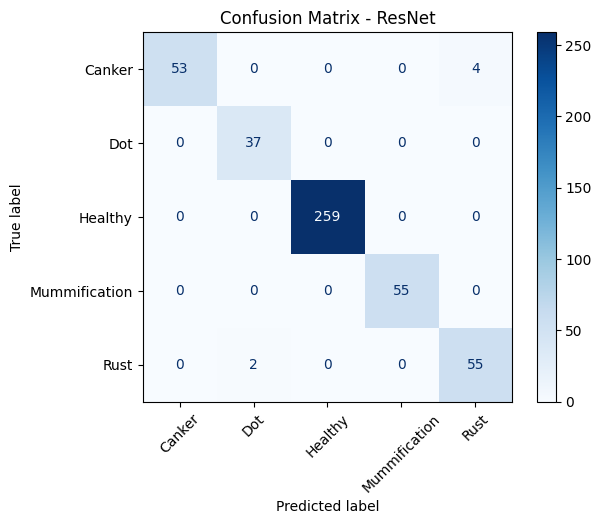

In [ ]:
# Additional metrics for ResNet
model_ft_resnet.eval()
all_preds = []
all_labels = []

class_names = ['Canker', 'Dot', 'Healthy', 'Mummification', 'Rust']

with torch.no_grad():
    for inputs, labels in dataloaders_dict['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_ft_resnet(inputs)
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
print("Confusion Matrix for ResNet:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# Classification Report
print("\nClassification Report for ResNet:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - ResNet")
plt.show()


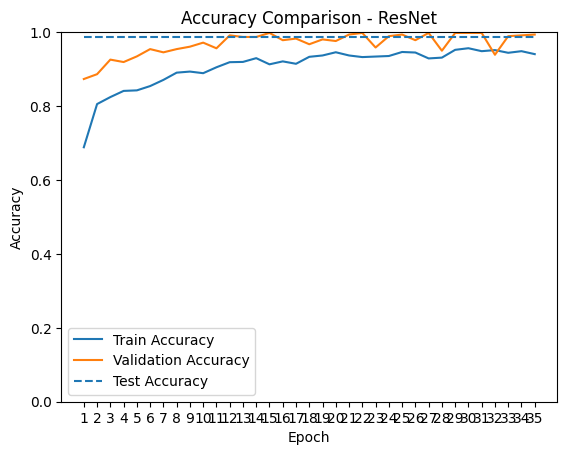

In [ ]:
E = 35
epochs = range(1, E + 1)

t_acc_resnet = np.array([h.cpu().numpy() for h in train_acc_history_resnet[:E]])
v_acc_resnet = np.array([h.cpu().numpy() for h in val_acc_history_resnet[:E]])

plt.title("Accuracy Comparison - ResNet")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.plot(epochs, t_acc_resnet, label="Train Accuracy")
plt.plot(epochs, v_acc_resnet, label="Validation Accuracy")

# Test accuracy as horizontal line
plt.hlines(
    y=test_acc_resnet,
    xmin=1,
    xmax=E,
    linestyles="dashed",
    label="Test Accuracy"
)

plt.ylim((0, 1))
plt.xticks(list(epochs))
plt.legend()
plt.show()


In [28]:
if train_model:
    # [resnet, alexnet, vgg, squeezenet, densenet, inception]
    model_name = "alexnet"
    feature_extract = True

    # Initialize the model for this run
    model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

    # Print the model we just instantiated
    print(model_ft)

    # Data augmentation and normalization for training
    # Just normalization for validation
    data_transforms = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(input_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'val': transforms.Compose([
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'test': transforms.Compose([   # ✅ ADD THIS
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
         ]),
    }

    print("Initializing Datasets and Dataloaders...")

    # Create training and validation datasets
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val', 'test']}
    # Create training and validation dataloaders
    dataloaders_dict = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True if x=='train' else False, num_workers=2) for x in ['train', 'val', 'test']}

    # Detect if we have a GPU available
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # Send the model to GPU
    model_ft = model_ft.to(device)
    summary(model_ft, (3, input_size, input_size))

    # Gather the parameters to be optimized/updated in this run. If we are
    #  finetuning we will be updating all parameters. However, if we are
    #  doing feature extract method, we will only update the parameters
    #  that we have just initialized, i.e. the parameters with requires_grad
    #  is True.
    params_to_update = model_ft.parameters()
    print("Params to learn:")
    if feature_extract:
        params_to_update = []
        for name,param in model_ft.named_parameters():
            if param.requires_grad == True:
                params_to_update.append(param)
                print("\t",name)
    else:
        for name,param in model_ft.named_parameters():
            if param.requires_grad == True:
                print("\t",name)

    # Observe that all parameters are being optimized
    optimizer_ft = optim.SGD(params_to_update, lr=0.001, momentum=0.9)

    # Setup the loss fxn
    criterion = nn.CrossEntropyLoss()

    # Train and evaluate
    model_ft_alexnet, train_loss_history_alexnet, train_acc_history_alexnet, val_loss_history_alexnet, val_acc_history_alexnet = train_model(model_ft, dataloaders_dict, criterion, optimizer_ft, num_epochs=30, is_inception=(model_name=="inception"))
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/'
    os.makedirs(path, exist_ok = True)
    torch.save(model_ft_alexnet.state_dict(), os.path.join(path,'model_ft_alexnet.pt'))
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/analytics/'
    os.makedirs(path, exist_ok = True)
    torch.save(torch.tensor(train_loss_history_alexnet), os.path.join(path,'train_loss_history_alexnet.pth'))
    torch.save(train_acc_history_alexnet, os.path.join(path,'train_acc_history_alexnet.pth'))
    torch.save(torch.tensor(val_loss_history_alexnet), os.path.join(path,'val_loss_history_alexnet.pth'))
    torch.save(val_acc_history_alexnet, os.path.join(path,'val_acc_history_alexnet.pth'))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 202MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

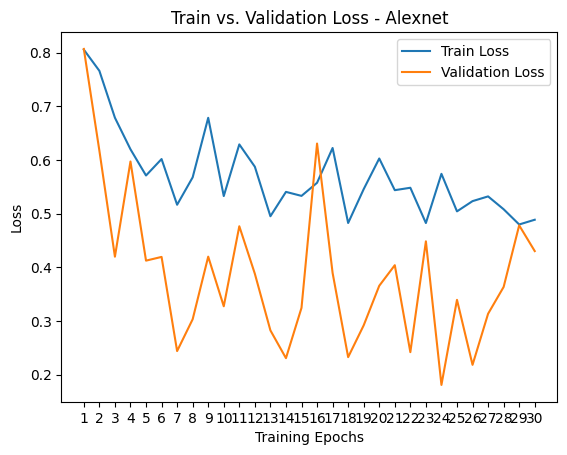

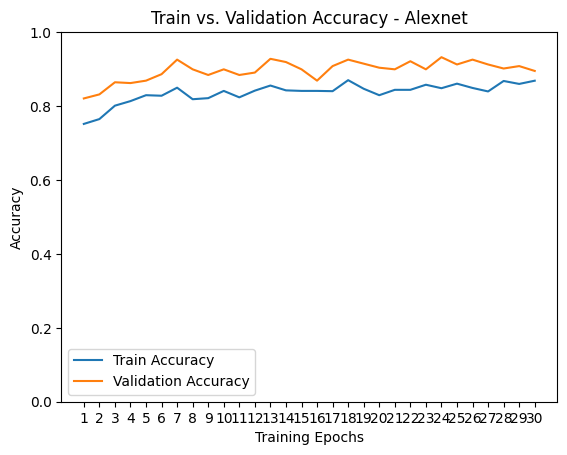

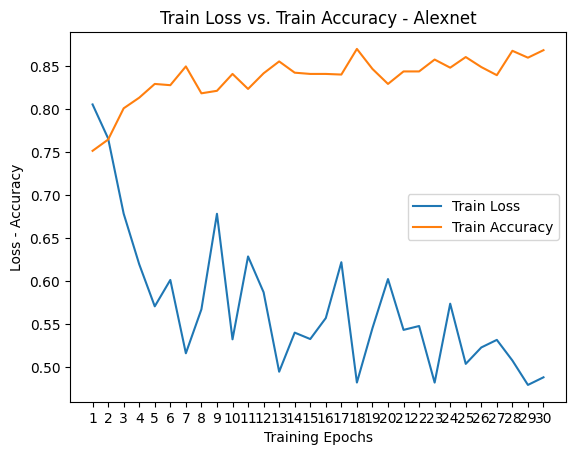

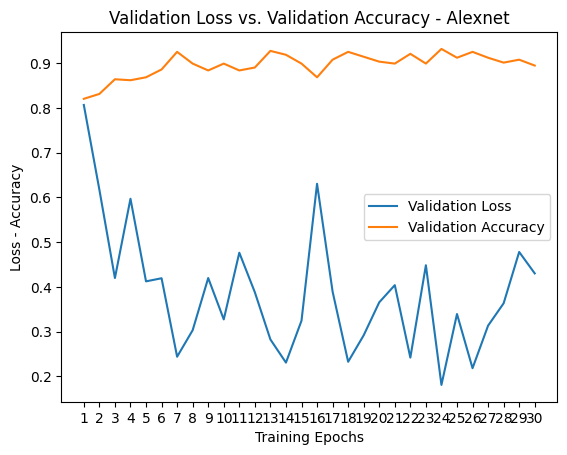

In [29]:
if train_model:
    E = len(train_loss_history_alexnet)
    # train_loss_history_alexnet, train_acc_history_alexnet, val_loss_history_alexnet, val_acc_history_alexnet
    t_loss_alexnet = [np.array(h) for h in train_loss_history_alexnet]
    v_loss_alexnet = [np.array(h) for h in val_loss_history_alexnet]
    plt.title("Train vs. Validation Loss - Alexnet")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss")
    plt.plot(range(1, E+1),t_loss_alexnet,label="Train Loss")
    plt.plot(range(1, E+1),v_loss_alexnet,label="Validation Loss")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()


    t_acc_alexnet = [h.cpu().numpy() for h in train_acc_history_alexnet]
    v_acc_alexnet = [h.cpu().numpy() for h in val_acc_history_alexnet]
    plt.title("Train vs. Validation Accuracy - Alexnet")
    plt.xlabel("Training Epochs")
    plt.ylabel("Accuracy")
    plt.plot(range(1, E+1),t_acc_alexnet,label="Train Accuracy")
    plt.plot(range(1, E+1),v_acc_alexnet,label="Validation Accuracy")
    plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()


    plt.title("Train Loss vs. Train Accuracy - Alexnet")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss - Accuracy")
    plt.plot(range(1, E+1),t_loss_alexnet,label="Train Loss")
    plt.plot(range(1, E+1),t_acc_alexnet,label="Train Accuracy")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()


    plt.title("Validation Loss vs. Validation Accuracy - Alexnet")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss - Accuracy")
    plt.plot(range(1, E+1),v_loss_alexnet,label="Validation Loss")
    plt.plot(range(1, E+1),v_acc_alexnet,label="Validation Accuracy")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()

In [30]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples

    return epoch_loss, epoch_acc.item()



In [31]:
test_loss_alexnet, test_acc_alexnet = evaluate_model(
    model_ft_alexnet,
    dataloaders_dict['test'],
    criterion,
    device
)

print(f"Test Loss AlexNet: {test_loss_alexnet:.4f}")
print(f"Test Accuracy AlexNet: {test_acc_alexnet:.4f}")



Test Loss AlexNet: 0.1900
Test Accuracy AlexNet: 0.9376


Confusion Matrix for AlexNet:
[[ 51   0   1   0   5]
 [  1  29   6   0   1]
 [  0   2 257   0   0]
 [  5   2   0  48   0]
 [  2   3   1   0  51]]

Classification Report for AlexNet:
               precision    recall  f1-score   support

       Canker       0.86      0.89      0.88        57
          Dot       0.81      0.78      0.79        37
      Healthy       0.97      0.99      0.98       259
Mummification       1.00      0.87      0.93        55
         Rust       0.89      0.89      0.89        57

     accuracy                           0.94       465
    macro avg       0.91      0.89      0.90       465
 weighted avg       0.94      0.94      0.94       465



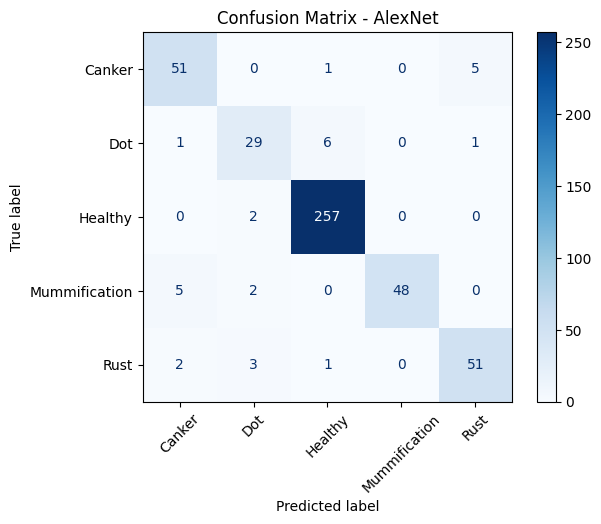

In [32]:
# Additional metrics for AlexNet
model_ft_alexnet.eval()
all_preds = []
all_labels = []

class_names = ['Canker', 'Dot', 'Healthy', 'Mummification', 'Rust']

with torch.no_grad():
    for inputs, labels in dataloaders_dict['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_ft_alexnet(inputs)
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
print("Confusion Matrix for AlexNet:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# Classification Report
print("\nClassification Report for AlexNet:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - AlexNet")
plt.show()


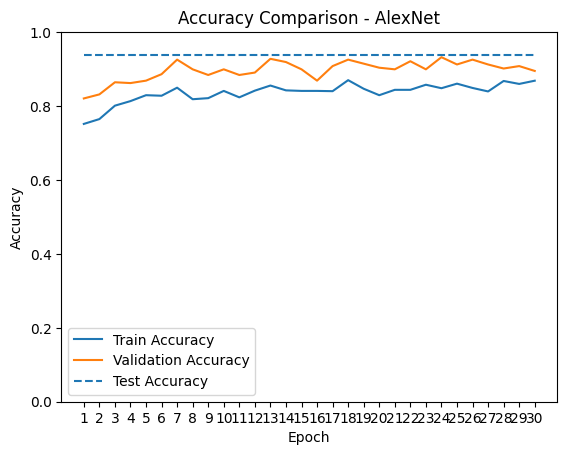

In [33]:
E = 30
epochs = range(1, E + 1)

t_acc_alexnet = np.array([h.cpu().numpy() for h in train_acc_history_alexnet[:E]])
v_acc_alexnet = np.array([h.cpu().numpy() for h in val_acc_history_alexnet[:E]])

plt.title("Accuracy Comparison - AlexNet")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.plot(epochs, t_acc_alexnet, label="Train Accuracy")
plt.plot(epochs, v_acc_alexnet, label="Validation Accuracy")

# Test accuracy as horizontal line
plt.hlines(
    y=test_acc_alexnet,
    xmin=1,
    xmax=E,
    linestyles="dashed",
    label="Test Accuracy"
)

plt.ylim((0, 1))
plt.xticks(list(epochs))
plt.legend()
plt.show()


In [22]:
if train_model:
    # [resnet, alexnet, vgg, squeezenet, densenet, inception]
    model_name = "vgg"
    feature_extract = True

    # Initialize the model for this run
    model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

    # Print the model we just instantiated
    print(model_ft)

    # Data augmentation and normalization for training
    # Just normalization for validation
    data_transforms = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(input_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'val': transforms.Compose([
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'test': transforms.Compose([   # ✅ ADD THIS
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
         ]),
    }

    print("Initializing Datasets and Dataloaders...")

    # Create training and validation datasets
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val', 'test']}
    # Create training and validation dataloaders
    dataloaders_dict = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True if x=='train' else False, num_workers=2) for x in ['train', 'val', 'test']}

    # Detect if we have a GPU available
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # Send the model to GPU
    model_ft = model_ft.to(device)
    summary(model_ft, (3, input_size, input_size))

    # Gather the parameters to be optimized/updated in this run. If we are
    #  finetuning we will be updating all parameters. However, if we are
    #  doing feature extract method, we will only update the parameters
    #  that we have just initialized, i.e. the parameters with requires_grad
    #  is True.
    params_to_update = model_ft.parameters()
    print("Params to learn:")
    if feature_extract:
        params_to_update = []
        for name,param in model_ft.named_parameters():
            if param.requires_grad == True:
                params_to_update.append(param)
                print("\t",name)
    else:
        for name,param in model_ft.named_parameters():
            if param.requires_grad == True:
                print("\t",name)

    # Observe that all parameters are being optimized
    optimizer_ft = optim.SGD(params_to_update, lr=0.001, momentum=0.9)

    # Setup the loss fxn
    criterion = nn.CrossEntropyLoss()

    # Train and evaluate
    model_ft_vgg, train_loss_history_vgg, train_acc_history_vgg, val_loss_history_vgg, val_acc_history_vgg = train_model(model_ft, dataloaders_dict, criterion, optimizer_ft, num_epochs=30, is_inception=(model_name=="inception"))
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/'
    os.makedirs(path, exist_ok = True)
    torch.save(model_ft_vgg.state_dict(), os.path.join(path,'model_ft_vgg.pt'))
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/analytics/'
    os.makedirs(path, exist_ok = True)
    torch.save(torch.tensor(train_loss_history_vgg), os.path.join(path,'train_loss_history_vgg.pth'))
    torch.save(train_acc_history_vgg, os.path.join(path,'train_acc_history_vgg.pth'))
    torch.save(torch.tensor(val_loss_history_vgg), os.path.join(path,'val_loss_history_vgg.pth'))
    torch.save(val_acc_history_vgg, os.path.join(path,'val_acc_history_vgg.pth'))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


100%|██████████| 528M/528M [00:02<00:00, 248MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

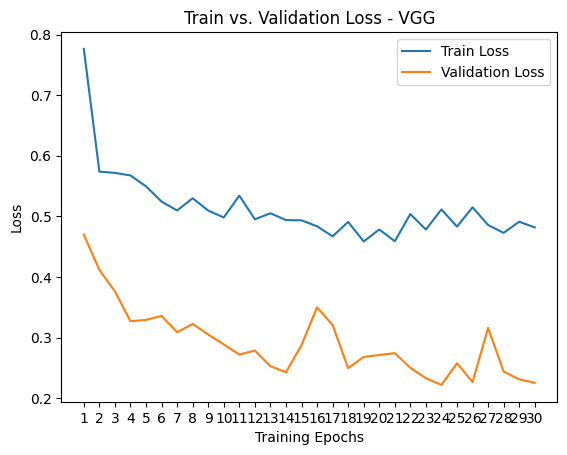

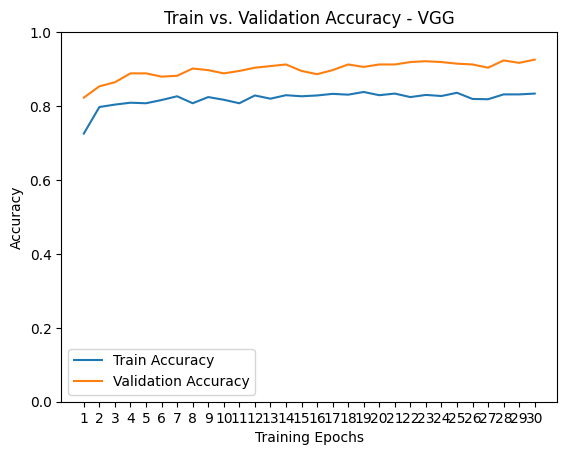

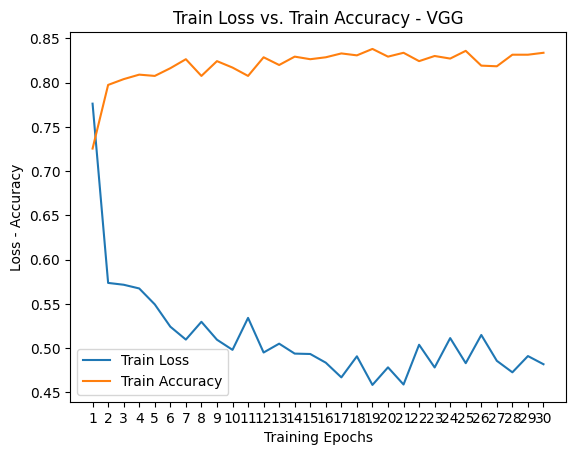

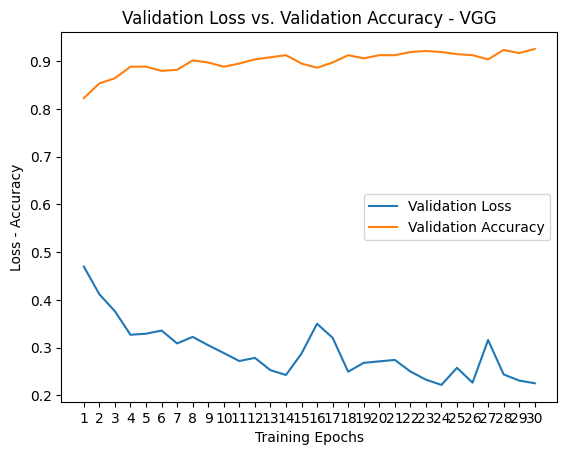

In [23]:
if train_model:
    E = len(train_loss_history_vgg)
    # train_loss_history_vgg, train_acc_history_vgg, val_loss_history_vgg, val_acc_history_vgg
    t_loss_vgg = [np.array(h) for h in train_loss_history_vgg]
    v_loss_vgg = [np.array(h) for h in val_loss_history_vgg]
    plt.title("Train vs. Validation Loss - VGG")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss")
    plt.plot(range(1, E+1),t_loss_vgg,label="Train Loss")
    plt.plot(range(1, E+1),v_loss_vgg,label="Validation Loss")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()


    t_acc_vgg = [h.cpu().numpy() for h in train_acc_history_vgg]
    v_acc_vgg = [h.cpu().numpy() for h in val_acc_history_vgg]
    plt.title("Train vs. Validation Accuracy - VGG")
    plt.xlabel("Training Epochs")
    plt.ylabel("Accuracy")
    plt.plot(range(1, E+1),t_acc_vgg,label="Train Accuracy")
    plt.plot(range(1, E+1),v_acc_vgg,label="Validation Accuracy")
    plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()


    plt.title("Train Loss vs. Train Accuracy - VGG")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss - Accuracy")
    plt.plot(range(1, E+1),t_loss_vgg,label="Train Loss")
    plt.plot(range(1, E+1),t_acc_vgg,label="Train Accuracy")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()


    plt.title("Validation Loss vs. Validation Accuracy - VGG")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss - Accuracy")
    plt.plot(range(1, E+1),v_loss_vgg,label="Validation Loss")
    plt.plot(range(1, E+1),v_acc_vgg,label="Validation Accuracy")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()

In [24]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples

    return epoch_loss, epoch_acc.item()



In [25]:
test_loss_vgg, test_acc_vgg = evaluate_model(
    model_ft_vgg,
    dataloaders_dict['test'],
    criterion,
    device
)

print(f"Test Loss VGG: {test_loss_vgg:.4f}")
print(f"Test Accuracy VGG: {test_acc_vgg:.4f}")




Test Loss VGG: 0.2164
Test Accuracy VGG: 0.9097


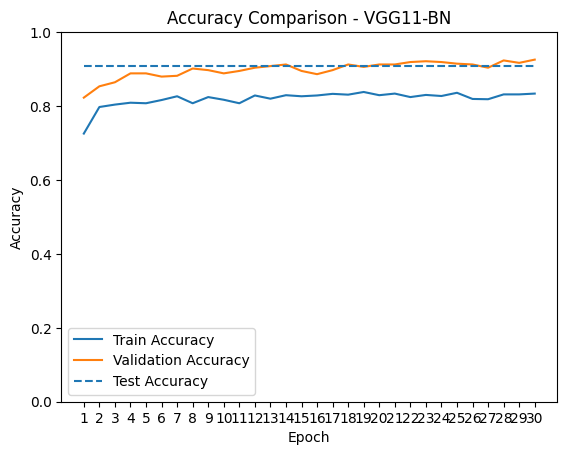

In [26]:
E = 30
epochs = range(1, E + 1)

t_acc_vgg = np.array([h.cpu().numpy() for h in train_acc_history_vgg[:E]])
v_acc_vgg = np.array([h.cpu().numpy() for h in val_acc_history_vgg[:E]])

plt.title("Accuracy Comparison - VGG11-BN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.plot(epochs, t_acc_vgg, label="Train Accuracy")
plt.plot(epochs, v_acc_vgg, label="Validation Accuracy")

# Test accuracy as horizontal line
plt.hlines(
    y=test_acc_vgg,
    xmin=1,
    xmax=E,
    linestyles="dashed",
    label="Test Accuracy"
)

plt.ylim((0, 1))
plt.xticks(list(epochs))
plt.legend()
plt.show()


Confusion Matrix for VGG:
[[ 50   2   1   2   2]
 [  6  18   6   1   6]
 [  0   0 258   0   1]
 [  4   0   0  48   3]
 [  4   0   1   3  49]]

Classification Report for VGG:
               precision    recall  f1-score   support

       Canker       0.78      0.88      0.83        57
          Dot       0.90      0.49      0.63        37
      Healthy       0.97      1.00      0.98       259
Mummification       0.89      0.87      0.88        55
         Rust       0.80      0.86      0.83        57

     accuracy                           0.91       465
    macro avg       0.87      0.82      0.83       465
 weighted avg       0.91      0.91      0.90       465



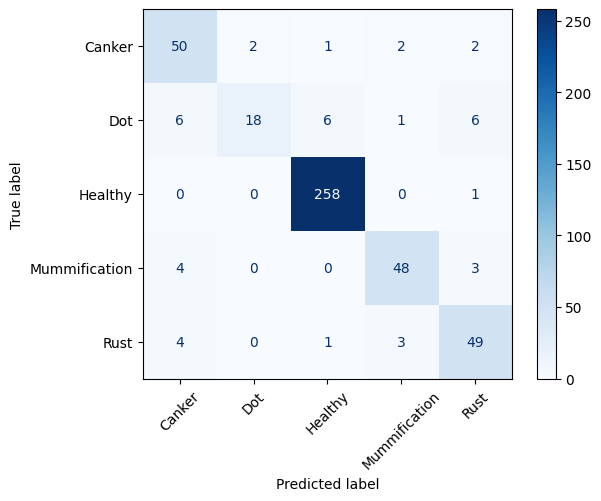

In [27]:
# Additional metrics for VGG
model_ft_vgg.eval()
all_preds = []
all_labels = []

class_names = ['Canker', 'Dot', 'Healthy', 'Mummification', 'Rust']

with torch.no_grad():
    for inputs, labels in dataloaders_dict['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_ft_vgg(inputs)
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Confusion Matrix for VGG:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

print("\nClassification Report for VGG:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.show()


In [14]:
if train_model:
    # [resnet, alexnet, vgg, squeezenet, densenet, inception]
    model_name = "squeezenet"
    feature_extract = True

    # Initialize the model for this run
    model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

    # Print the model we just instantiated
    print(model_ft)

    # Data augmentation and normalization for training
    # Just normalization for validation
    data_transforms = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(input_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'val': transforms.Compose([
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
         'test': transforms.Compose([   # ✅ ADD THIS
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
         ]),
    }

    print("Initializing Datasets and Dataloaders...")

    # Create training and validation datasets
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val', 'test']}
    # Create training and validation dataloaders
    dataloaders_dict = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True if x=='train' else False, num_workers=2) for x in ['train', 'val', 'test']}

    # Detect if we have a GPU available
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # Send the model to GPU
    model_ft = model_ft.to(device)
    summary(model_ft, (3, input_size, input_size))

    # Gather the parameters to be optimized/updated in this run. If we are
    #  finetuning we will be updating all parameters. However, if we are
    #  doing feature extract method, we will only update the parameters
    #  that we have just initialized, i.e. the parameters with requires_grad
    #  is True.
    params_to_update = model_ft.parameters()
    print("Params to learn:")
    if feature_extract:
        params_to_update = []
        for name,param in model_ft.named_parameters():
            if param.requires_grad == True:
                params_to_update.append(param)
                print("\t",name)
    else:
        for name,param in model_ft.named_parameters():
            if param.requires_grad == True:
                print("\t",name)

    # Observe that all parameters are being optimized
    optimizer_ft = optim.SGD(params_to_update, lr=0.001, momentum=0.9)

    # Setup the loss fxn
    criterion = nn.CrossEntropyLoss()

    # Train and evaluate
    model_ft_squeezenet, train_loss_history_squeezenet, train_acc_history_squeezenet, val_loss_history_squeezenet, val_acc_history_squeezenet = train_model(model_ft, dataloaders_dict, criterion, optimizer_ft, num_epochs=25, is_inception=(model_name=="inception"))
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/'
    os.makedirs(path, exist_ok = True)
    torch.save(model_ft_squeezenet.state_dict(), os.path.join(path,'model_ft_squeezenet.pt'))
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/analytics/'
    os.makedirs(path, exist_ok = True)
    torch.save(torch.tensor(train_loss_history_squeezenet), os.path.join(path,'train_loss_history_squeezenet.pth'))
    torch.save(train_acc_history_squeezenet, os.path.join(path,'train_acc_history_squeezenet.pth'))
    torch.save(torch.tensor(val_loss_history_squeezenet), os.path.join(path,'val_loss_history_squeezenet.pth'))
    torch.save(val_acc_history_squeezenet, os.path.join(path,'val_acc_history_squeezenet.pth'))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/squeezenet1_0-b66bff10.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_0-b66bff10.pth


100%|██████████| 4.78M/4.78M [00:00<00:00, 201MB/s]


SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): Fire(
   

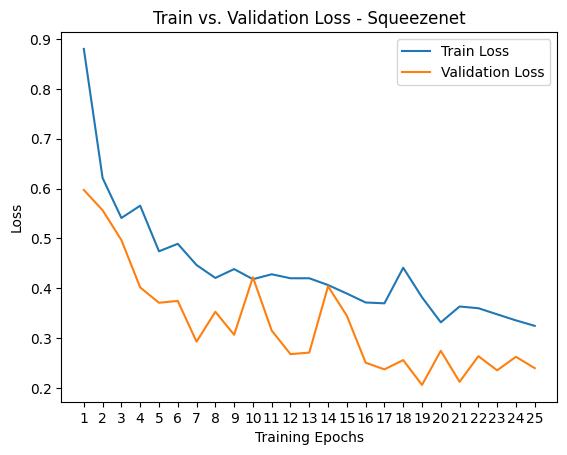

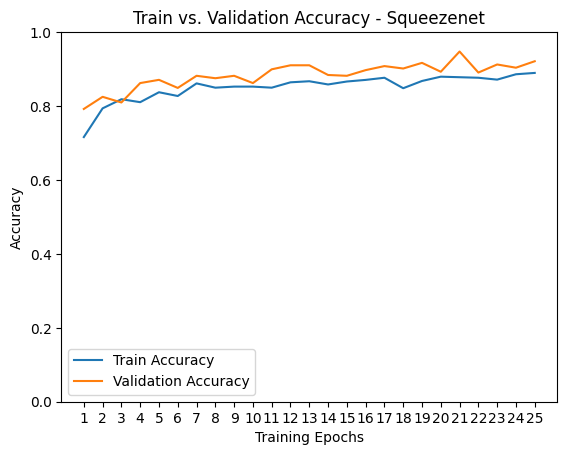

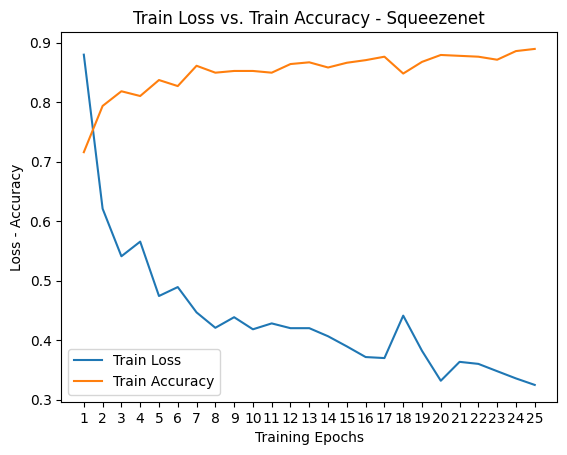

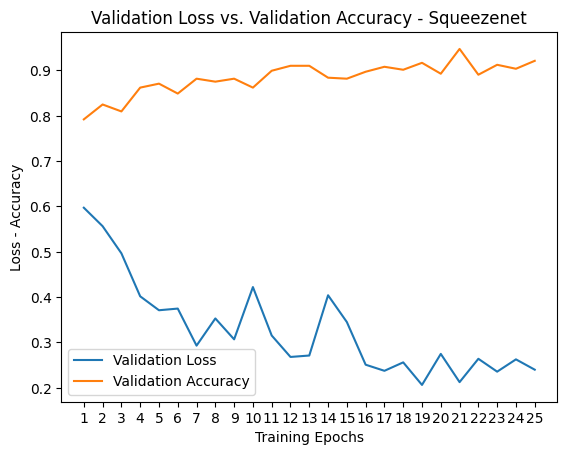

In [15]:
if train_model:
    E = len(train_loss_history_squeezenet)
    # train_loss_history_squeezenet, train_acc_history_squeezenet, val_loss_history_squeezenet, val_acc_history_squeezenet
    t_loss_squeezenet = [np.array(h) for h in train_loss_history_squeezenet]
    v_loss_squeezenet = [np.array(h) for h in val_loss_history_squeezenet]
    plt.title("Train vs. Validation Loss - Squeezenet")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss")
    plt.plot(range(1, E+1),t_loss_squeezenet,label="Train Loss")
    plt.plot(range(1, E+1),v_loss_squeezenet,label="Validation Loss")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()


    t_acc_squeezenet = [h.cpu().numpy() for h in train_acc_history_squeezenet]
    v_acc_squeezenet = [h.cpu().numpy() for h in val_acc_history_squeezenet]
    plt.title("Train vs. Validation Accuracy - Squeezenet")
    plt.xlabel("Training Epochs")
    plt.ylabel("Accuracy")
    plt.plot(range(1, E+1),t_acc_squeezenet,label="Train Accuracy")
    plt.plot(range(1, E+1),v_acc_squeezenet,label="Validation Accuracy")
    plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()


    plt.title("Train Loss vs. Train Accuracy - Squeezenet")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss - Accuracy")
    plt.plot(range(1, E+1),t_loss_squeezenet,label="Train Loss")
    plt.plot(range(1, E+1),t_acc_squeezenet,label="Train Accuracy")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()


    plt.title("Validation Loss vs. Validation Accuracy - Squeezenet")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss - Accuracy")
    plt.plot(range(1, E+1),v_loss_squeezenet,label="Validation Loss")
    plt.plot(range(1, E+1),v_acc_squeezenet,label="Validation Accuracy")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()

In [16]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples

    return epoch_loss, epoch_acc.item()



In [17]:
test_loss_squeezenet, test_acc_squeezenet = evaluate_model(
    model_ft_squeezenet,
    dataloaders_dict['test'],
    criterion,
    device
)

print(f"Test Loss SqueezeNet: {test_loss_squeezenet:.4f}")
print(f"Test Accuracy SqueezeNet: {test_acc_squeezenet:.4f}")


Test Loss SqueezeNet: 0.2040
Test Accuracy SqueezeNet: 0.9333


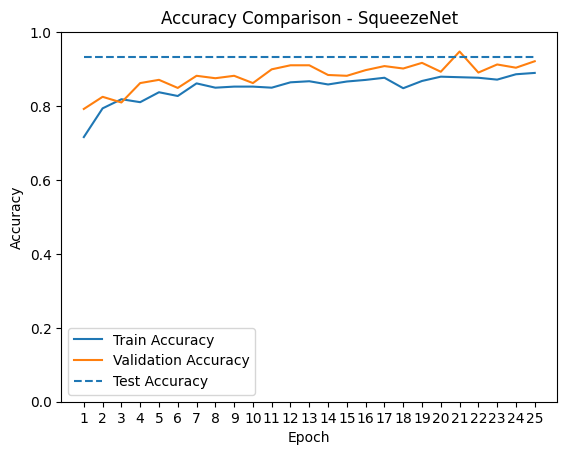

In [18]:
E = 25
epochs = range(1, E + 1)

t_acc_squeezenet = np.array([h.cpu().numpy() for h in train_acc_history_squeezenet[:E]])
v_acc_squeezenet = np.array([h.cpu().numpy() for h in val_acc_history_squeezenet[:E]])

plt.title("Accuracy Comparison - SqueezeNet")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.plot(epochs, t_acc_squeezenet, label="Train Accuracy")
plt.plot(epochs, v_acc_squeezenet, label="Validation Accuracy")

# Test accuracy as horizontal line
plt.hlines(
    y=test_acc_squeezenet,
    xmin=1,
    xmax=E,
    linestyles="dashed",
    label="Test Accuracy"
)

plt.ylim((0, 1))
plt.xticks(list(epochs))
plt.legend()
plt.show()


Confusion Matrix for SqueezeNet:
[[ 56   0   0   0   1]
 [  2  25   4   0   6]
 [  1   1 254   0   3]
 [  6   1   0  48   0]
 [  3   1   1   1  51]]

Classification Report for SqueezeNet:
               precision    recall  f1-score   support

       Canker       0.82      0.98      0.90        57
          Dot       0.89      0.68      0.77        37
      Healthy       0.98      0.98      0.98       259
Mummification       0.98      0.87      0.92        55
         Rust       0.84      0.89      0.86        57

     accuracy                           0.93       465
    macro avg       0.90      0.88      0.89       465
 weighted avg       0.94      0.93      0.93       465



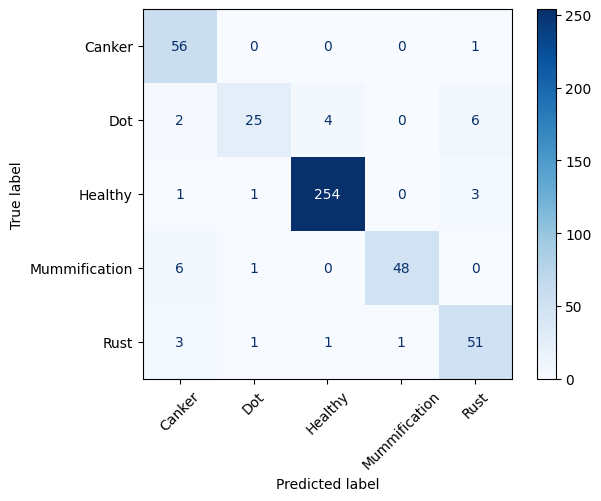

In [25]:
# Additional metrics for SqueezeNet
model_ft_squeezenet.eval()
all_preds = []
all_labels = []

class_names = ['Canker', 'Dot', 'Healthy', 'Mummification', 'Rust']

with torch.no_grad():
    for inputs, labels in dataloaders_dict['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_ft_squeezenet(inputs)
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Confusion Matrix for SqueezeNet:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

print("\nClassification Report for SqueezeNet:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.show()


In [19]:
 if train_model:
    # [resnet, alexnet, vgg, squeezenet, densenet, inception]
    model_name = "densenet"
    feature_extract = True

    # Initialize the model for this run
    model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

    # Print the model we just instantiated
    print(model_ft)

    # Data augmentation and normalization for training
    # Just normalization for validation
    data_transforms = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(input_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'val': transforms.Compose([
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'test': transforms.Compose([   # ✅ ADD THIS
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
         ]),
    }

    print("Initializing Datasets and Dataloaders...")

    # Create training and validation datasets
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val', 'test']}
    # Create training and validation dataloaders
    dataloaders_dict = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True if x=='train' else False, num_workers=2) for x in ['train', 'val', 'test']}

    # Detect if we have a GPU available
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # Send the model to GPU
    model_ft = model_ft.to(device)
    # summary(model_ft, (3, input_size, input_size))

    # Gather the parameters to be optimized/updated in this run. If we are
    #  finetuning we will be updating all parameters. However, if we are
    #  doing feature extract method, we will only update the parameters
    #  that we have just initialized, i.e. the parameters with requires_grad
    #  is True.
    params_to_update = model_ft.parameters()
    print("Params to learn:")
    if feature_extract:
        params_to_update = []
        for name,param in model_ft.named_parameters():
            if param.requires_grad == True:
                params_to_update.append(param)
                print("\t",name)
    else:
        for name,param in model_ft.named_parameters():
            if param.requires_grad == True:
                print("\t",name)

    # Observe that all parameters are being optimized
    optimizer_ft = optim.SGD(params_to_update, lr=0.001, momentum=0.9)

    # Setup the loss fxn
    criterion = nn.CrossEntropyLoss()

    # Train and evaluate
    model_ft_densenet, train_loss_history_densenet, train_acc_history_densenet, val_loss_history_densenet, val_acc_history_densenet = train_model(model_ft, dataloaders_dict, criterion, optimizer_ft, num_epochs=30, is_inception=(model_name=="inception"))
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/'
    os.makedirs(path, exist_ok = True)
    torch.save(model_ft_densenet.state_dict(), os.path.join(path,'model_ft_densenet.pt'))
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/analytics/'
    os.makedirs(path, exist_ok = True)
    torch.save(torch.tensor(train_loss_history_densenet), os.path.join(path,'train_loss_history_densenet.pth'))
    torch.save(train_acc_history_densenet, os.path.join(path,'train_acc_history_densenet.pth'))
    torch.save(torch.tensor(val_loss_history_densenet), os.path.join(path,'val_loss_history_densenet.pth'))
    torch.save(val_acc_history_densenet, os.path.join(path,'val_acc_history_densenet.pth'))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 260MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

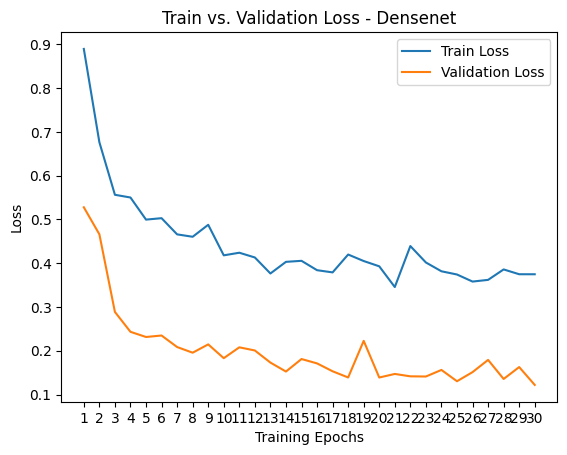

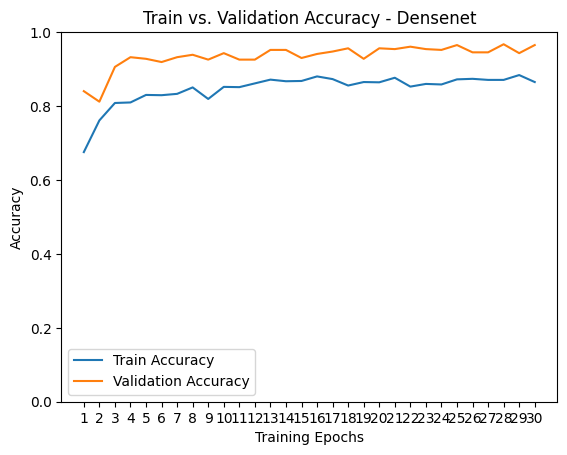

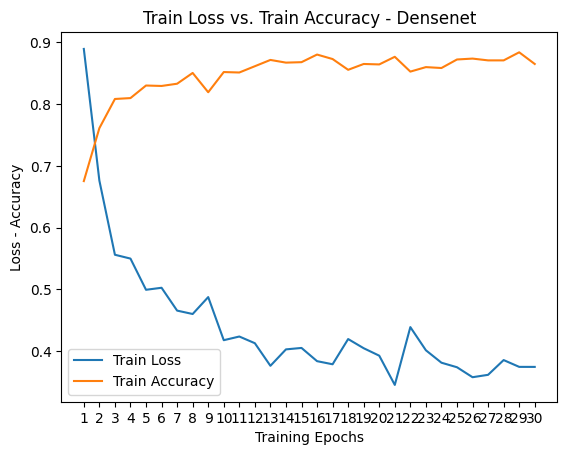

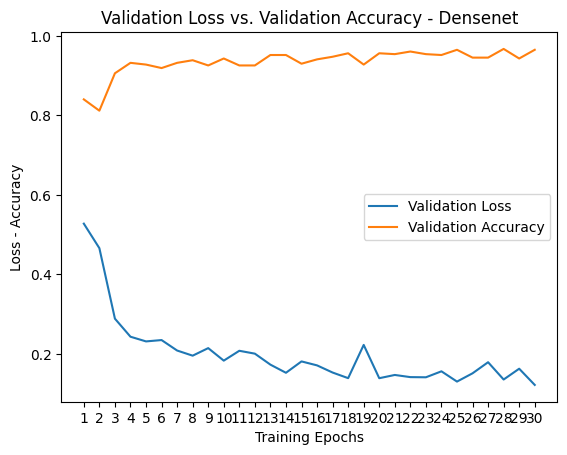

In [20]:
if train_model:
    E = len(train_loss_history_densenet)
    # train_loss_history_densenet, train_acc_history_densenet, val_loss_history_densenet, val_acc_history_densenet
    t_loss_densenet = [np.array(h) for h in train_loss_history_densenet]
    v_loss_densenet = [np.array(h) for h in val_loss_history_densenet]
    plt.title("Train vs. Validation Loss - Densenet")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss")
    plt.plot(range(1, E+1),t_loss_densenet,label="Train Loss")
    plt.plot(range(1, E+1),v_loss_densenet,label="Validation Loss")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()


    t_acc_densenet = [h.cpu().numpy() for h in train_acc_history_densenet]
    v_acc_densenet = [h.cpu().numpy() for h in val_acc_history_densenet]
    plt.title("Train vs. Validation Accuracy - Densenet")
    plt.xlabel("Training Epochs")
    plt.ylabel("Accuracy")
    plt.plot(range(1, E+1),t_acc_densenet,label="Train Accuracy")
    plt.plot(range(1, E+1),v_acc_densenet,label="Validation Accuracy")
    plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()


    plt.title("Train Loss vs. Train Accuracy - Densenet")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss - Accuracy")
    plt.plot(range(1, E+1),t_loss_densenet,label="Train Loss")
    plt.plot(range(1, E+1),t_acc_densenet,label="Train Accuracy")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()


    plt.title("Validation Loss vs. Validation Accuracy - Densenet")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss - Accuracy")
    plt.plot(range(1, E+1),v_loss_densenet,label="Validation Loss")
    plt.plot(range(1, E+1),v_acc_densenet,label="Validation Accuracy")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, E+1, 1.0))
    plt.legend()
    plt.show()

In [21]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples

    return epoch_loss, epoch_acc.item()



In [22]:
test_loss_densenet, test_acc_densenet = evaluate_model(
    model_ft_densenet,
    dataloaders_dict['test'],
    criterion,
    device
)

print(f"Test Loss DenseNet: {test_loss_densenet:.4f}")
print(f"Test Accuracy DenseNet: {test_acc_densenet:.4f}")


Test Loss DenseNet: 0.1344
Test Accuracy DenseNet: 0.9634


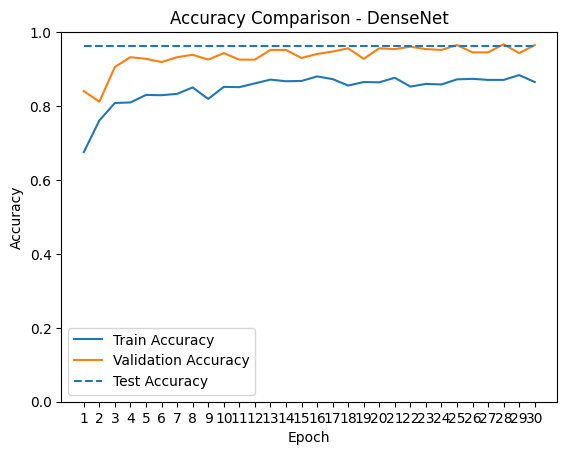

In [23]:
E = 30
epochs = range(1, E + 1)

t_acc_densenet = np.array([h.cpu().numpy() for h in train_acc_history_densenet[:E]])
v_acc_densenet = np.array([h.cpu().numpy() for h in val_acc_history_densenet[:E]])

plt.title("Accuracy Comparison - DenseNet")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.plot(epochs, t_acc_densenet, label="Train Accuracy")
plt.plot(epochs, v_acc_densenet, label="Validation Accuracy")

# Test accuracy as horizontal line
plt.hlines(
    y=test_acc_densenet,
    xmin=1,
    xmax=E,
    linestyles="dashed",
    label="Test Accuracy"
)

plt.ylim((0, 1))
plt.xticks(list(epochs))
plt.legend()
plt.show()


Confusion Matrix for DenseNet:
[[ 55   0   0   0   2]
 [  2  34   0   0   1]
 [  0   2 255   0   2]
 [  2   1   0  51   1]
 [  1   2   0   1  53]]

Classification Report for DenseNet:
               precision    recall  f1-score   support

       Canker       0.92      0.96      0.94        57
          Dot       0.87      0.92      0.89        37
      Healthy       1.00      0.98      0.99       259
Mummification       0.98      0.93      0.95        55
         Rust       0.90      0.93      0.91        57

     accuracy                           0.96       465
    macro avg       0.93      0.95      0.94       465
 weighted avg       0.96      0.96      0.96       465



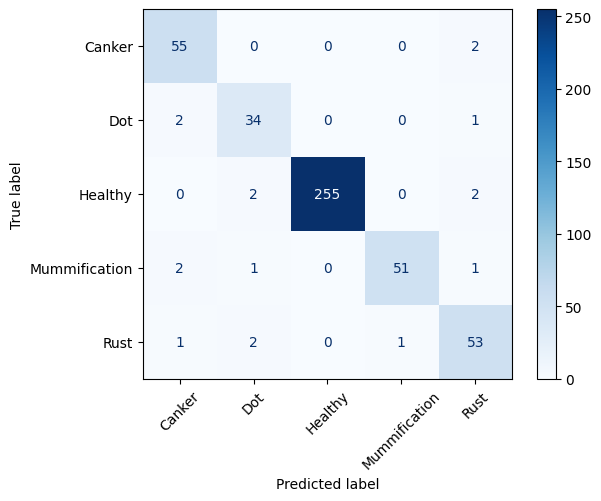

In [24]:
# Additional metrics for DenseNet
model_ft_densenet.eval()
all_preds = []
all_labels = []

class_names = ['Canker', 'Dot', 'Healthy', 'Mummification', 'Rust']

with torch.no_grad():
    for inputs, labels in dataloaders_dict['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_ft_densenet(inputs)
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Confusion Matrix for DenseNet:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

print("\nClassification Report for DenseNet:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.show()


In [13]:
if train_model:
    # [resnet, alexnet, vgg, squeezenet, densenet, inception]
    model_name = "inception"
    feature_extract = True

    # Initialize the model for this run
    model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

    # Print the model we just instantiated
    print(model_ft)

    # Data augmentation and normalization for training
    # Just normalization for validation
    data_transforms = {
        'train': transforms.Compose([
            transforms.Resize(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'val': transforms.Compose([
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'test': transforms.Compose([   # ✅ ADD THIS
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
         ]),
    }

    print("Initializing Datasets and Dataloaders...")

    # Create training and validation datasets
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val', 'test']}
    # Create training and validation dataloaders
    dataloaders_dict = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True if x=='train' else False, num_workers=2) for x in ['train', 'val', 'test']}

    # Detect if we have a GPU available
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # Send the model to GPU
    model_ft = model_ft.to(device)
    summary(model_ft, (3, input_size, input_size))

    # Gather the parameters to be optimized/updated in this run. If we are
    #  finetuning we will be updating all parameters. However, if we are
    #  doing feature extract method, we will only update the parameters
    #  that we have just initialized, i.e. the parameters with requires_grad
    #  is True.
    params_to_update = model_ft.parameters()
    print("Params to learn:")
    if feature_extract:
        params_to_update = []
        for name,param in model_ft.named_parameters():
            if param.requires_grad == True:
                params_to_update.append(param)
                print("\t",name)
    else:
        for name,param in model_ft.named_parameters():
            if param.requires_grad == True:
                print("\t",name)

    # Observe that all parameters are being optimized
    optimizer_ft = optim.SGD(params_to_update, lr=0.001, momentum=0.9)

    # Setup the loss fxn
    criterion = nn.CrossEntropyLoss()

    # Train and evaluate
    model_ft_inception, train_loss_history_inception, train_acc_history_inception, val_loss_history_inception, val_acc_history_inception = train_model(model_ft, dataloaders_dict, criterion, optimizer_ft, num_epochs=30, is_inception=(model_name=="inception"))
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/'
    os.makedirs(path, exist_ok = True)
    torch.save(model_ft_inception.state_dict(), os.path.join(path,'model_ft_inception.pt'))
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/analytics/'
    os.makedirs(path, exist_ok = True)
    torch.save(torch.tensor(train_loss_history_inception), os.path.join(path,'train_loss_history_inception.pth'))
    torch.save(train_acc_history_inception, os.path.join(path,'train_acc_history_inception.pth'))
    torch.save(torch.tensor(val_loss_history_inception), os.path.join(path,'val_loss_history_inception.pth'))
    torch.save(val_acc_history_inception, os.path.join(path,'val_acc_history_inception.pth'))

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

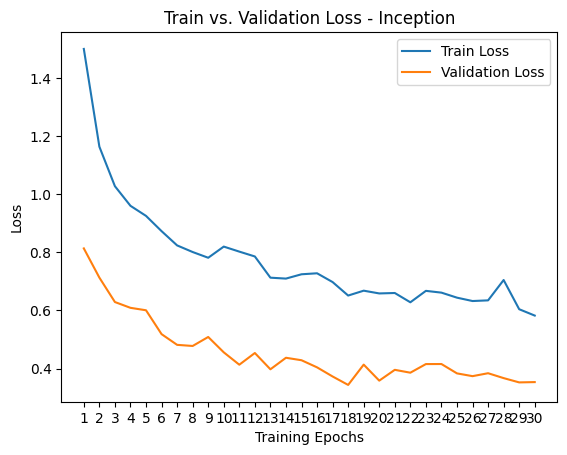

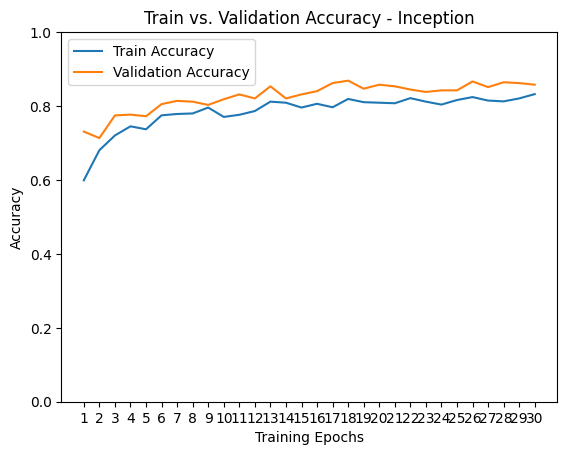

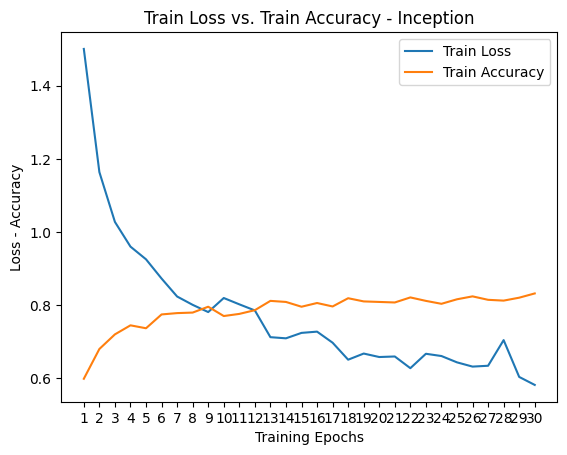

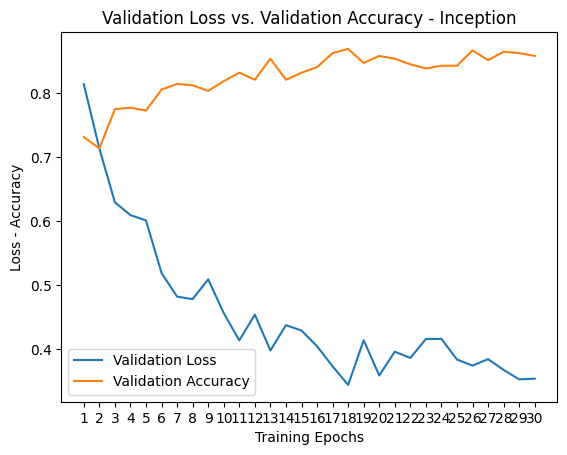

In [15]:
num_epochs=30
if train_model:
    # train_loss_history_inception, train_acc_history_inception, val_loss_history_inception, val_acc_history_inception
    t_loss_inception = [np.array(h) for h in train_loss_history_inception]
    v_loss_inception = [np.array(h) for h in val_loss_history_inception]
    plt.title("Train vs. Validation Loss - Inception")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss")
    plt.plot(range(1,num_epochs+1),t_loss_inception,label="Train Loss")
    plt.plot(range(1,num_epochs+1),v_loss_inception,label="Validation Loss")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, num_epochs+1, 1.0))
    plt.legend()
    plt.show()


    t_acc_inception = [h.cpu().numpy() for h in train_acc_history_inception]
    v_acc_inception = [h.cpu().numpy() for h in val_acc_history_inception]
    plt.title("Train vs. Validation Accuracy - Inception")
    plt.xlabel("Training Epochs")
    plt.ylabel("Accuracy")
    plt.plot(range(1,num_epochs+1),t_acc_inception,label="Train Accuracy")
    plt.plot(range(1,num_epochs+1),v_acc_inception,label="Validation Accuracy")
    plt.ylim((0,1.))
    plt.xticks(np.arange(1, num_epochs+1, 1.0))
    plt.legend()
    plt.show()


    plt.title("Train Loss vs. Train Accuracy - Inception")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss - Accuracy")
    plt.plot(range(1,num_epochs+1),t_loss_inception,label="Train Loss")
    plt.plot(range(1,num_epochs+1),t_acc_inception,label="Train Accuracy")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, num_epochs+1, 1.0))
    plt.legend()
    plt.show()


    plt.title("Validation Loss vs. Validation Accuracy - Inception")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss - Accuracy")
    plt.plot(range(1,num_epochs+1),v_loss_inception,label="Validation Loss")
    plt.plot(range(1,num_epochs+1),v_acc_inception,label="Validation Accuracy")
    #plt.ylim((0,1.))
    plt.xticks(np.arange(1, num_epochs+1, 1.0))
    plt.legend()
    plt.show()

In [16]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples

    return epoch_loss, epoch_acc.item()



In [17]:
test_loss_inception, test_acc_inception = evaluate_model(
    model_ft_inception,
    dataloaders_dict['test'],
    criterion,
    device
)

print(f"Test Loss Inception-v3: {test_loss_inception:.4f}")
print(f"Test Accuracy Inception-v3: {test_acc_inception:.4f}")


Test Loss Inception-v3: 0.3599
Test Accuracy Inception-v3: 0.8624


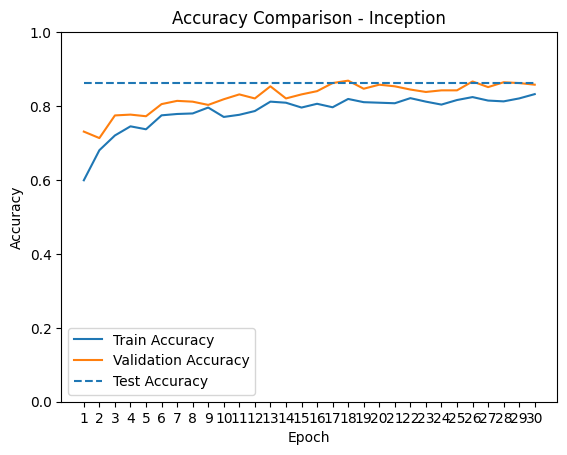

In [20]:
E = 30
epochs = range(1, E + 1)

t_acc_inception = np.array([h.cpu().numpy() for h in train_acc_history_inception[:E]])
v_acc_inception = np.array([h.cpu().numpy() for h in val_acc_history_inception[:E]])

plt.title("Accuracy Comparison - Inception")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.plot(epochs, t_acc_inception, label="Train Accuracy")
plt.plot(epochs, v_acc_inception, label="Validation Accuracy")

# Test accuracy as horizontal line
plt.hlines(
    y=test_acc_inception,
    xmin=1,
    xmax=E,
    linestyles="dashed",
    label="Test Accuracy"
)

plt.ylim((0, 1))
plt.xticks(list(epochs))
plt.legend()
plt.show()


Confusion Matrix for Inception:
[[ 46   4   0   1   6]
 [  3  23   2   1   8]
 [  0   6 253   0   0]
 [  5   2   0  45   3]
 [ 11   4   8   0  34]]

Classification Report for Inception:
               precision    recall  f1-score   support

       Canker       0.71      0.81      0.75        57
          Dot       0.59      0.62      0.61        37
      Healthy       0.96      0.98      0.97       259
Mummification       0.96      0.82      0.88        55
         Rust       0.67      0.60      0.63        57

     accuracy                           0.86       465
    macro avg       0.78      0.76      0.77       465
 weighted avg       0.86      0.86      0.86       465



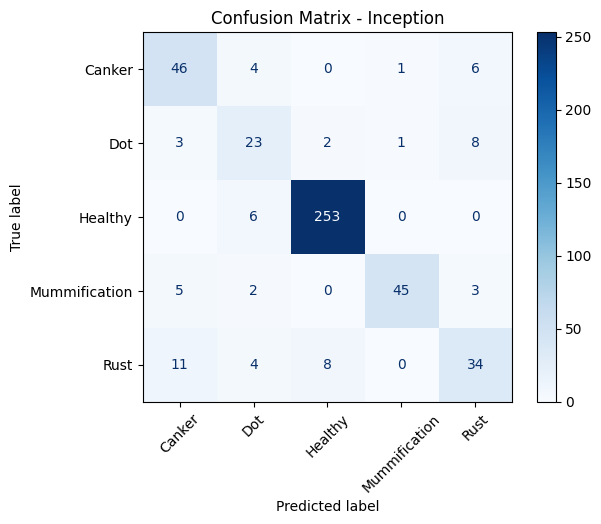

In [21]:
# Additional metrics for Inception-v3
model_ft_inception.eval()
all_preds = []
all_labels = []

class_names = ['Canker', 'Dot', 'Healthy', 'Mummification', 'Rust']

with torch.no_grad():
    for inputs, labels in dataloaders_dict['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_ft_inception(inputs)
        # Inception may return (logits, aux_logits)
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
print("Confusion Matrix for Inception:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# Classification Report
print("\nClassification Report for Inception:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Inception")
plt.show()


In [ ]:
if train_model:
    # [resnet, alexnet, vgg, squeezenet, densenet, inception, efficientnet]
    model_name = "efficientnet"
    feature_extract = False

    # Initialize the model for this run
    model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

    # Print the model we just instantiated
    print(model_ft)

    # Data augmentation and normalization for training
    data_transforms = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(input_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'val': transforms.Compose([
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'test': transforms.Compose([
            transforms.Resize(input_size),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
    }

    print("Initializing Datasets and Dataloaders...")

    # Create training, validation, and test datasets
    image_datasets = {
        x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
        for x in ['train', 'val', 'test']
    }

    # Create training, validation, and test dataloaders
    dataloaders_dict = {
        x: torch.utils.data.DataLoader(
            image_datasets[x],
            batch_size=batch_size,
            shuffle=True if x == 'train' else False,
            num_workers=2
        )
        for x in ['train', 'val', 'test']
    }

    # Detect if we have a GPU available
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # Send the model to GPU
    model_ft = model_ft.to(device)
    summary(model_ft, (3, input_size, input_size))

    # Gather parameters to be optimized/updated in this run
    params_to_update = model_ft.parameters()
    print("Params to learn:")
    if feature_extract:
        params_to_update = []
        for name, param in model_ft.named_parameters():
            if param.requires_grad:
                params_to_update.append(param)
                print("\t", name)
    else:
        for name, param in model_ft.named_parameters():
            if param.requires_grad:
                print("\t", name)

    # Optimizer
    optimizer_ft = optim.SGD(params_to_update, lr=0.001, momentum=0.9)

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Train and evaluate
    model_ft_eff, train_loss_history_eff, train_acc_history_eff, val_loss_history_eff, val_acc_history_eff = train_model(
        model_ft,
        dataloaders_dict,
        criterion,
        optimizer_ft,
        num_epochs=25,
        is_inception=False
    )

    # Save model and analytics
    path = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/'
    os.makedirs(path, exist_ok=True)
    torch.save(model_ft_eff.state_dict(), os.path.join(path, 'model_ft_efficientnet_b0.pth'))

    path_analytics = '/content/drive/My Drive/Guava_disease/model/feature_extraction/40/analytics/'
    os.makedirs(path_analytics, exist_ok=True)
    torch.save(torch.tensor(train_loss_history_eff), os.path.join(path_analytics, 'train_loss_history_eff.pth'))
    torch.save(train_acc_history_eff, os.path.join(path_analytics, 'train_acc_history_eff.pth'))
    torch.save(torch.tensor(val_loss_history_eff), os.path.join(path_analytics, 'val_loss_history_eff.pth'))
    torch.save(val_acc_history_eff, os.path.join(path_analytics, 'val_acc_history_eff.pth'))


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 209MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
num_epochs = 25

if train_model:
    # train_loss_history_eff, train_acc_history_eff, val_loss_history_eff, val_acc_history_eff

    t_loss_eff = [np.array(h) for h in train_loss_history_eff]
    v_loss_eff = [np.array(h) for h in val_loss_history_eff]

    plt.title("Train vs. Validation Loss - EfficientNet-B0")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss")
    plt.plot(range(1, num_epochs + 1), t_loss_eff, label="Train Loss")
    plt.plot(range(1, num_epochs + 1), v_loss_eff, label="Validation Loss")
    plt.xticks(np.arange(1, num_epochs + 1, 1.0))
    plt.legend()
    plt.show()

    t_acc_eff = [h.cpu().numpy() for h in train_acc_history_eff]
    v_acc_eff = [h.cpu().numpy() for h in val_acc_history_eff]

    plt.title("Train vs. Validation Accuracy - EfficientNet-B0")
    plt.xlabel("Training Epochs")
    plt.ylabel("Accuracy")
    plt.plot(range(1, num_epochs + 1), t_acc_eff, label="Train Accuracy")
    plt.plot(range(1, num_epochs + 1), v_acc_eff, label="Validation Accuracy")
    plt.ylim((0, 1.))
    plt.xticks(np.arange(1, num_epochs + 1, 1.0))
    plt.legend()
    plt.show()

    plt.title("Train Loss vs. Train Accuracy - EfficientNet-B0")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss - Accuracy")
    plt.plot(range(1, num_epochs + 1), t_loss_eff, label="Train Loss")
    plt.plot(range(1, num_epochs + 1), t_acc_eff, label="Train Accuracy")
    plt.xticks(np.arange(1, num_epochs + 1, 1.0))
    plt.legend()
    plt.show()

    plt.title("Validation Loss vs. Validation Accuracy - EfficientNet-B0")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss - Accuracy")
    plt.plot(range(1, num_epochs + 1), v_loss_eff, label="Validation Loss")
    plt.plot(range(1, num_epochs + 1), v_acc_eff, label="Validation Accuracy")
    plt.xticks(np.arange(1, num_epochs + 1, 1.0))
    plt.legend()
    plt.show()


NameError: name 'train_model' is not defined

In [ ]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples

    return epoch_loss, epoch_acc.item()



In [ ]:
test_loss_eff, test_acc_eff = evaluate_model(
    model_ft_eff,
    dataloaders_dict['test'],
    criterion,
    device
)

print(f"Test Loss EfficientNet-B0: {test_loss_eff:.4f}")
print(f"Test Accuracy EfficientNet-B0: {test_acc_eff:.2f}")


NameError: name 'evaluate_model' is not defined

Confusion Matrix for EfficientNet-B0:
[[ 55   0   0   1   1]
 [  0  37   0   0   0]
 [  0   0 259   0   0]
 [  0   0   0  55   0]
 [  0   0   0   0  57]]

Classification Report for EfficientNet-B0:
               precision    recall  f1-score   support

       Canker       1.00      0.96      0.98        57
          Dot       1.00      1.00      1.00        37
      Healthy       1.00      1.00      1.00       259
Mummification       0.98      1.00      0.99        55
         Rust       0.98      1.00      0.99        57

     accuracy                           1.00       465
    macro avg       0.99      0.99      0.99       465
 weighted avg       1.00      1.00      1.00       465



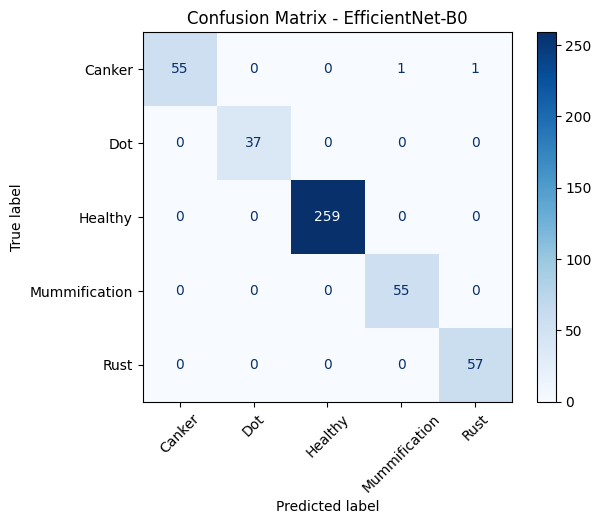

In [ ]:
# Additional metrics for EfficientNet-B0
model_ft_eff.eval()
all_preds = []
all_labels = []

class_names = ['Canker', 'Dot', 'Healthy', 'Mummification', 'Rust']

with torch.no_grad():
    for inputs, labels in dataloaders_dict['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_ft_eff(inputs)
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
print("Confusion Matrix for EfficientNet-B0:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# Classification Report
print("\nClassification Report for EfficientNet-B0:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - EfficientNet-B0")
plt.show()


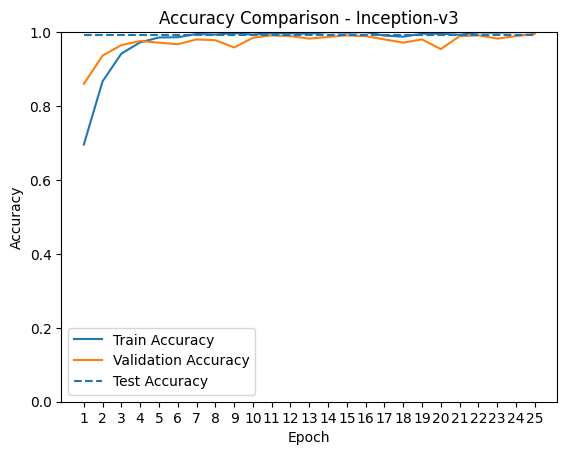

In [ ]:
E = 25
epochs = range(1, E + 1)

t_acc_inception = np.array([h.cpu().numpy() for h in train_acc_history_inception[:E]])
v_acc_inception = np.array([h.cpu().numpy() for h in val_acc_history_inception[:E]])

plt.title("Accuracy Comparison - Inception-v3")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.plot(epochs, t_acc_inception, label="Train Accuracy")
plt.plot(epochs, v_acc_inception, label="Validation Accuracy")

# Test accuracy as horizontal line
plt.hlines(
    y=test_acc_inception,
    xmin=1,
    xmax=E,
    linestyles="dashed",
    label="Test Accuracy"
)

plt.ylim((0, 1))
plt.xticks(list(epochs))
plt.legend()
plt.show()


Comparative Analysis:
          Model  Test Accuracy  Test Loss
0        ResNet       0.987097   0.045153
1       AlexNet       0.995699   0.014833
2           VGG       0.997849   0.015003
3    SqueezeNet       0.978495   0.068254
4      DenseNet       0.989247   0.019914
5     Inception       0.993548   0.010156
6  EfficientNet       0.995699   0.029755

Best Model: VGG with Test Accuracy: 0.9978


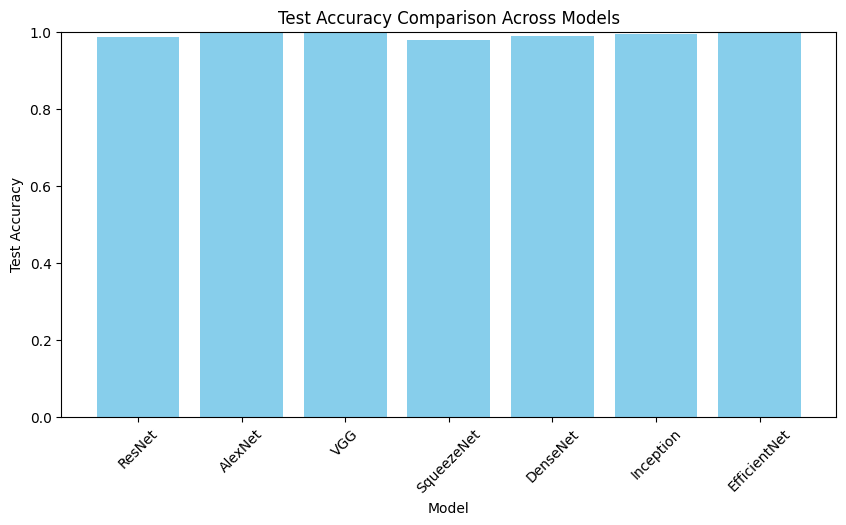

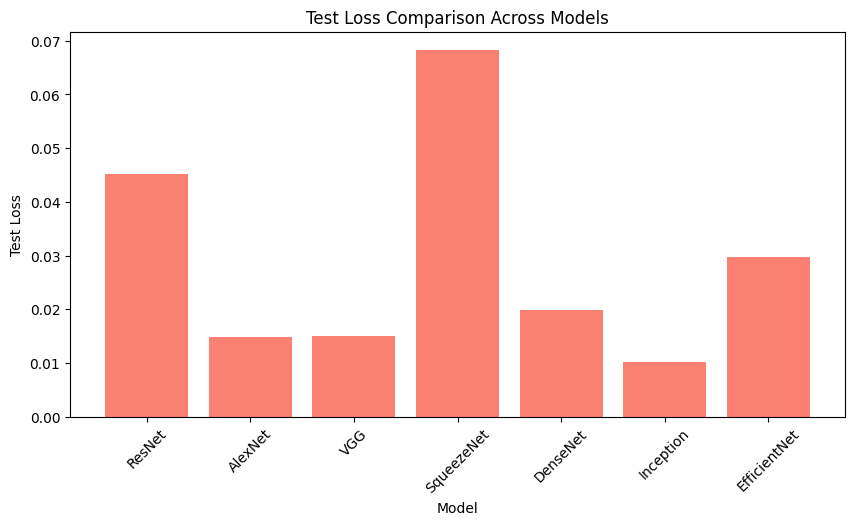

In [ ]:
# Comparative Analysis of All Models

import pandas as pd

# Assuming the test accuracies and losses are stored in variables like test_acc_resnet, etc.
# If not, you can run the evaluations above and collect them.

models = ['ResNet', 'AlexNet', 'VGG', 'SqueezeNet', 'DenseNet', 'Inception', 'EfficientNet']
test_accuracies = [test_acc_resnet, test_acc_alexnet, test_acc_vgg, test_acc_squeezenet, test_acc_densenet, test_acc_inception, test_acc_eff]
test_losses = [test_loss_resnet, test_loss_alexnet, test_loss_vgg, test_loss_squeezenet, test_loss_densenet, test_loss_inception, test_loss_eff]

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': models,
    'Test Accuracy': test_accuracies,
    'Test Loss': test_losses
})

print("Comparative Analysis:")
print(comparison_df)

# Find the best model
best_acc_idx = comparison_df['Test Accuracy'].idxmax()
best_model = comparison_df.loc[best_acc_idx, 'Model']
best_acc = comparison_df.loc[best_acc_idx, 'Test Accuracy']

print(f"\nBest Model: {best_model} with Test Accuracy: {best_acc:.4f}")

# Optional: Plot comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(models, test_accuracies, color='skyblue')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Comparison Across Models')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(models, test_losses, color='salmon')
plt.xlabel('Model')
plt.ylabel('Test Loss')
plt.title('Test Loss Comparison Across Models')
plt.xticks(rotation=45)
plt.show()